# RQ4 — Does the proficiency of the code in a PR affect the review effort it receives?

Companion to `rq3_task_type_proficiency.ipynb`. Same three groups, same per-PR
proficiency measures; the outcome here is the human review effort each PR attracted.

**Independent variables** (both already in the per-group CSVs)

| Variable | Meaning |
|---|---|
| `cefr_mean` | ordinal CEFR mean over the PR's constructs, A1=1 … C2=6 — the measure used for RQ2's repository-paired Wilcoxon |
| `c1c2` | number of proficient (C1 + C2) constructs the PR introduces |

Both are standardised, so every coefficient is the effect of a **one standard deviation
increase**. `c1c2` is log(1+x) transformed first: it is extremely right-skewed (median 1,
maximum 1,015).

**Dependent variables** — all restricted to *human* activity, because bots write 41% of
the reviews and 70% of the comments on agent PRs.

| Variable | Meaning |
|---|---|
| `rounds` | human review submissions (`n_reviews_human`) |
| `comments` | review and conversation comments written by humans other than the PR author |
| `changes` | whether any human reviewer requested changes |

**Models.** PR size is the confound: bigger PRs attract both more comments and, simply by
holding more code, more proficient constructs. Every estimate below therefore comes from a
regression that controls for added lines, deleted lines, changed files and task type, with
standard errors clustered by repository. Counts use negative binomial regression;
the yes/no outcome uses logistic regression.

In [1]:
import os
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from patsy import dmatrices, dmatrix

warnings.simplefilter('ignore')

# Resolve paths whether the kernel starts in analysis/ or in the repository root.
CWD = os.getcwd()
ROOT = os.path.dirname(CWD) if os.path.basename(CWD) == 'analysis' else CWD
DATA = os.path.join(ROOT, 'analysis')
FIG_DIR = ROOT                                   # paper.tex includes figures from the root
TAB_DIR = os.path.join(DATA, 'rq4_tables')
os.makedirs(TAB_DIR, exist_ok=True)

LEVELS = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']
GROUPS = ['AI agents', 'Human', 'Human (pre-ChatGPT)']
SHORT = {'AI agents': 'agents', 'Human': 'human', 'Human (pre-ChatGPT)': 'pre_chatgpt'}
FILES = {
    'AI agents':           'rq3_agent_prs_with_task_type.csv',
    'Human':               'rq3_human_prs_with_task_type.csv',
    'Human (pre-ChatGPT)': 'rq3_pre_chatgpt_prs_with_task_type.csv',
}
COMMENT_AUTHORS = 'rq4_pr_comment_authors.csv'   # human/bot split, from rq4_fetch_comment_authors.py

# Task types with few PRs are pooled into "other" so the dummies stay estimable.
KEEP_TASKS = ['feat', 'fix', 'refactor', 'test', 'docs']
TASK_ORDER = ['feat', 'fix', 'refactor', 'test', 'docs', 'other']

IVS = {'cefr_z': 'Ordinal CEFR mean', 'c1c2_z': 'C1+C2 constructs'}
OUTCOMES = {'rounds': 'Review rounds', 'comments': 'Review comments',
            'changes': 'Changes requested'}

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
print('ROOT =', ROOT)

ROOT = /Users/chaiyong/Downloads/do_not_delete/2026-AIDevAgentCEFR-EMSE


## 1. Load, check, and derive the model variables

The three per-group CSVs already carry the CEFR counts, the proficiency measures, the PR
size controls and the review metrics. `status` records whether the PR could still be read
from GitHub; 15 PRs were deleted upstream and are dropped here.

In [2]:
frames = []
for g, f in FILES.items():
    d = pd.read_csv(os.path.join(DATA, f), dtype={'pr_id': str})
    assert (d['group'] == g).all(), f'{f}: unexpected group label'
    frames.append(d)
raw = pd.concat(frames, ignore_index=True)

print('PRs before the status filter:', len(raw))
print(raw.groupby('group')['status'].value_counts().rename('n').to_frame().T)

df = raw[raw['status'] == 'ok'].copy()
df['group'] = pd.Categorical(df['group'], categories=GROUPS, ordered=True)

# Same consistency checks as the RQ3 notebook: the shipped columns must match the counts.
assert df['pr_id'].is_unique
assert (df[LEVELS].sum(axis=1) == df['total']).all()
assert ((df['C1'] + df['C2']) == df['c1c2']).all()
ordinal = (df[LEVELS] * np.arange(1, 7)).sum(axis=1) / df['total']
assert np.allclose(ordinal, df['cefr_mean'], atol=1e-3)
print('\nPRs after the status filter:', len(df))

PRs before the status filter: 1481
group  AI agents     Human     Human (pre-ChatGPT)
status        ok 404    ok 404                  ok
n            489   2   500  13                 477

PRs after the status filter: 1466


### Human-only comment counts

`n_review_comments` and `n_issue_comments` are GitHub's own counters and **include bot
comments**. `rq4_fetch_comment_authors.py` re-fetches each PR's comments and splits them
by author, which is what the human-only outcome needs. If that file is absent the notebook
falls back to the raw counters and flags it, so every result stays reproducible either way.

In [3]:
ca_path = os.path.join(DATA, COMMENT_AUTHORS)
HUMAN_COMMENTS = os.path.exists(ca_path)

if HUMAN_COMMENTS:
    ca = pd.read_csv(ca_path, dtype={'pr_id': str})
    cols = ['pr_id', 'n_review_comments_human', 'n_issue_comments_human',
            'n_review_comments_bot', 'n_issue_comments_bot',
            'n_review_comments_author', 'n_issue_comments_author', 'comment_status']
    df = df.merge(ca[cols], on='pr_id', how='left')
    miss = int(df['n_review_comments_human'].isna().sum())
    print(f'comment author split merged; {len(df) - miss}/{len(df)} PRs matched')
    for c in cols[1:-1]:
        df[c] = df[c].fillna(0).astype(int)

    # Reconcile against the counters stored by the first fetch.
    for kind in ['review', 'issue']:
        tot = df[f'n_{kind}_comments_human'] + df[f'n_{kind}_comments_bot']
        agree = (tot == df[f'n_{kind}_comments'].fillna(0)).mean()
        print(f'  {kind:6s} comments reconcile with the stored counter for {agree*100:.1f}% of PRs')

    df['comments_human'] = df['n_review_comments_human'] + df['n_issue_comments_human']
    df['comments_bot'] = df['n_review_comments_bot'] + df['n_issue_comments_bot']
    df['comments_author'] = df['n_review_comments_author'] + df['n_issue_comments_author']
    # The PR author's own replies are not reviewer effort, and leaving them in would bias
    # the between-group comparison: on agent PRs the author is a bot and is already
    # excluded by the bot filter, while on human PRs the author writes a large share of
    # the human comments.
    df['comments'] = df['comments_human'] - df['comments_author']
else:
    print('!! rq4_pr_comment_authors.csv not found -- falling back to GitHub\'s raw counters,')
    print('   which include bot comments. Run rq4_fetch_comment_authors.py for the human-only split.')
    df['comments'] = (df['n_review_comments'].fillna(0) + df['n_issue_comments'].fillna(0))
    df['comments_human'] = df['comments']
    df['comments_bot'] = np.nan
    df['comments_author'] = np.nan

df['comments'] = df['comments'].astype(int)
df['rounds'] = df['n_reviews_human'].fillna(0).astype(int)
df['changes'] = df['any_changes_requested'].fillna(0).astype(int)
print('\nHUMAN_COMMENTS =', HUMAN_COMMENTS)

comment author split merged; 1466/1466 PRs matched
  review comments reconcile with the stored counter for 100.0% of PRs
  issue  comments reconcile with the stored counter for 100.0% of PRs

HUMAN_COMMENTS = True


In [4]:
# --- predictors ---------------------------------------------------------------
df['task'] = np.where(df['type'].isin(KEEP_TASKS), df['type'], 'other')
df['task'] = pd.Categorical(df['task'], categories=TASK_ORDER)   # feat is the reference

for col, src in [('log_add', 'additions'), ('log_del', 'deletions'),
                 ('log_files', 'changed_files')]:
    df[col] = np.log1p(df[src].astype(float))

df['log_c1c2'] = np.log1p(df['c1c2'].astype(float))


def z(s):
    return (s - s.mean()) / s.std(ddof=0)


# Standardised on the pooled sample so the three groups share one scale.
df['cefr_z'] = z(df['cefr_mean'])
df['c1c2_z'] = z(df['log_c1c2'])
df['c1c2pct_z'] = z(df['c1c2_pct'].fillna(0))

SD = {'cefr_mean': df['cefr_mean'].std(ddof=0), 'log_c1c2': df['log_c1c2'].std(ddof=0)}
print('1 SD of the ordinal CEFR mean  =', round(SD['cefr_mean'], 4))
print('1 SD of log(1 + C1+C2)         =', round(SD['log_c1c2'], 4),
      f'(a factor of {np.exp(SD["log_c1c2"]):.2f} in 1 + C1+C2)')
print('\ntask types after pooling:')
print(pd.crosstab(df['task'], df['group']))

1 SD of the ordinal CEFR mean  = 0.5455
1 SD of log(1 + C1+C2)         = 1.3003 (a factor of 3.67 in 1 + C1+C2)

task types after pooling:
group     AI agents  Human  Human (pre-ChatGPT)
task                                           
feat            236    225                  122
fix             165    162                  168
refactor         35     34                   40
test             21     18                   35
docs             16     21                   17
other            16     40                   95


## 2. How much review effort is there to explain?

The RQ4 proposal asks for this check before any modelling: if almost every PR received no
human review at all, RQ4 would have to be reported descriptively rather than fitted.

In [5]:
def desc(d):
    r, c = d['rounds'], d['comments']
    out = {
        'PRs': len(d), 'repositories': d['repo'].nunique(),
        'rounds: zero %': 100 * (r == 0).mean(), 'rounds: median': r.median(),
        'rounds: mean': r.mean(), 'rounds: max': r.max(),
        'comments: zero %': 100 * (c == 0).mean(), 'comments: median': c.median(),
        'comments: mean': c.mean(), 'comments: max': c.max(),
        'changes requested %': 100 * d['changes'].mean(),
        'reviews by bots %': 100 * d['n_reviews_bot'].fillna(0).sum()
                             / max(1, d['n_reviews_total'].fillna(0).sum()),
    }
    if HUMAN_COMMENTS:
        allc = d['comments_human'].sum() + d['comments_bot'].sum()
        out['comments by bots %'] = 100 * d['comments_bot'].sum() / max(1, allc)
        out['human comments by the PR author %'] = (100 * d['comments_author'].sum()
                                                    / max(1, d['comments_human'].sum()))
    return pd.Series(out)


descriptives = pd.DataFrame({g: desc(d) for g, d in df.groupby('group', observed=True)})
print(descriptives.to_string())

                                   AI agents   Human  Human (pre-ChatGPT)
PRs                                  489.000 500.000              477.000
repositories                         129.000 143.000               49.000
rounds: zero %                        31.697  33.400               36.897
rounds: median                         1.000   1.000                1.000
rounds: mean                           2.249   2.250                1.836
rounds: max                           32.000  50.000               33.000
comments: zero %                      39.877  57.600               56.813
comments: median                       1.000   0.000                0.000
comments: mean                         3.305   1.808                1.692
comments: max                         50.000  35.000               31.000
changes requested %                   10.429   4.000                5.031
reviews by bots %                     41.614  20.043                4.262
comments by bots %                    

In [6]:
# Dispersion: for a Poisson process the variance would equal the mean. It does not.
disp = pd.DataFrame({
    g: {f'{o} var/mean': d[o].var() / max(1e-9, d[o].mean()) for o in ['rounds', 'comments']}
    for g, d in df.groupby('group', observed=True)})
print(disp.to_string())
print('\nA ratio far above 1 is overdispersion, which is why the counts are modelled')
print('with a negative binomial rather than a Poisson regression.')

                   AI agents  Human  Human (pre-ChatGPT)
rounds var/mean        5.995  8.564                5.550
comments var/mean     13.313  9.558                7.030

A ratio far above 1 is overdispersion, which is why the counts are modelled
with a negative binomial rather than a Poisson regression.


In [ ]:
# Figures: the distribution of review effort per group, one file per measure.
FACE = ['#ffffff', '#c8c8c8', '#8c8c8c']
FIGSIZE = (6.5, 3.2)


def save_fig(fig, name):
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIG_DIR, f'{name}.{ext}'),
                    bbox_inches='tight', dpi=200 if ext == 'png' else None)
    plt.show()


# The two counts, as grouped histograms; the long tail is folded into the last bar.
for col, label, cap, step, name in [
        ('rounds', 'Human review rounds per PR', 12, 1, 'rq4_dist_rounds'),
        ('comments', 'Reviewer comments per PR', 20, 5, 'rq4_dist_comments')]:
    fig, ax = plt.subplots(figsize=FIGSIZE)
    bins = np.arange(0, cap + 2) - 0.5
    for i, g in enumerate(GROUPS):
        v = df.loc[df.group == g, col].clip(upper=cap)
        h, _ = np.histogram(v, bins=bins)
        ax.bar(np.arange(0, cap + 1) + (i - 1) * 0.28, 100 * h / h.sum(), width=0.28,
               facecolor=FACE[i], edgecolor='black', linewidth=0.6, label=g)
    ticks = list(range(0, cap + 1, step))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t}+' if t == cap else str(t) for t in ticks], fontsize=9)
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel('% of PRs', fontsize=10)
    ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, frameon=False)
    save_fig(fig, name)

# The binary outcome, as one bar per group.
fig, ax = plt.subplots(figsize=FIGSIZE)
vals = [100 * df.loc[df.group == g, 'changes'].mean() for g in GROUPS]
bars = ax.bar(range(3), vals, width=0.6, edgecolor='black', linewidth=0.6)
for b, f, v in zip(bars, FACE, vals):
    b.set_facecolor(f)
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, max(vals) * 1.15)                      # headroom so the top label is not clipped
ax.set_xticks(range(3))
ax.set_xticklabels(GROUPS, fontsize=9)
ax.set_ylabel('% of PRs with changes requested', fontsize=10)
ax.grid(True, axis='y', ls='--', lw=0.5, alpha=0.6)
ax.set_axisbelow(True)
save_fig(fig, 'rq4_dist_changes')

## 3. Raw association, before controlling for size

Reported only to make the confound visible: PR size drives both proficiency and review
effort, so these raw correlations are not the answer to RQ4.

In [8]:
def holm(pvals):
    p = np.asarray(pvals, dtype=float)
    order = np.argsort(p)
    adj = np.empty_like(p)
    running = 0.0
    for rank, idx in enumerate(order):
        running = max(running, (len(p) - rank) * p[idx])
        adj[idx] = min(running, 1.0)
    return adj


rows = []
for g, d in df.groupby('group', observed=True):
    for xn, x in [('cefr_mean', d['cefr_mean']), ('c1c2', d['c1c2']),
                  ('additions', d['additions'])]:
        for yn in ['rounds', 'comments']:
            r, p = stats.spearmanr(x, d[yn])
            rows.append(dict(group=g, predictor=xn, outcome=yn, rho=r, p=p))
spear = pd.DataFrame(rows)
spear['p_holm'] = holm(spear['p'])
print(spear.pivot_table(index=['group', 'predictor'], columns='outcome',
                        values=['rho', 'p_holm']).to_string())

                                p_holm             rho       
outcome                       comments rounds comments rounds
group               predictor                                
AI agents           additions    0.178  0.178    0.107 -0.109
                    c1c2         0.024  1.000    0.141 -0.001
                    cefr_mean    1.000  1.000    0.027  0.006
Human               additions    0.000  0.357    0.208  0.092
                    c1c2         0.001  0.025    0.176  0.138
                    cefr_mean    1.000  1.000    0.030  0.006
Human (pre-ChatGPT) additions    0.019  1.000    0.147  0.003
                    c1c2         0.000  0.112    0.210  0.119
                    cefr_mean    1.000  1.000    0.011  0.054


## 4. The models

One model per (group, outcome, proficiency measure). Counts use a negative binomial
regression, the yes/no outcome a logistic regression; both control for
`log(1+additions)`, `log(1+deletions)`, `log(1+changed files)` and task type, with
standard errors clustered by repository.

Coefficients are exponentiated: an **incidence rate ratio** for the counts (the
multiplicative change in the expected number of reviews or comments per 1 SD of
proficiency) and an **odds ratio** for changes requested. A value of 1 means proficiency
makes no difference.

In [9]:
CONTROLS = 'log_add + log_del + log_files + C(task)'


def fit_one(d, outcome, iv, kind, controls=CONTROLS):
    """One clustered model. Returns (result, formula) or (None, formula) if it fails."""
    formula = f'{outcome} ~ {iv} + {controls}'
    groups = d['repo'].astype('category').cat.codes.values
    kw = dict(cov_type='cluster', cov_kwds={'groups': groups}, maxiter=1000, disp=0)
    try:
        if kind == 'nb':
            res = smf.negativebinomial(formula, d).fit(**kw)
        else:
            # Newton can stall on the sparse changes-requested outcome; BFGS reaches the
            # same optimum and reports convergence honestly.
            res = smf.logit(formula, d).fit(method='bfgs', **kw)
        return res, formula
    except Exception as e:                                    # noqa: BLE001
        print(f'  FAILED {formula} on {len(d)} rows: {type(e).__name__}: {e}')
        return None, formula


def effect(res, iv):
    """Exponentiated coefficient of `iv` with its 95% CI and p-value."""
    lo, hi = res.conf_int().loc[iv]
    return dict(est=np.exp(res.params[iv]), lo=np.exp(lo), hi=np.exp(hi),
                p=res.pvalues[iv],
                converged=bool(res.mle_retvals.get('converged', True)))


def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

In [10]:
records, fits = [], {}
for g, d in df.groupby('group', observed=True):
    for outcome in OUTCOMES:
        kind = 'logit' if outcome == 'changes' else 'nb'
        for iv in IVS:
            res, _ = fit_one(d, outcome, iv, kind)
            if res is None:
                continue
            fits[(g, outcome, iv)] = res
            rec = dict(group=g, outcome=outcome, iv=iv, kind=kind,
                       n=int(res.nobs), repos=d['repo'].nunique(),
                       events=int(d['changes'].sum()) if outcome == 'changes' else np.nan,
                       alpha=float(res.params.get('alpha', np.nan)),
                       pseudo_r2=float(getattr(res, 'prsquared', np.nan)))
            rec.update(effect(res, iv))
            records.append(rec)

models = pd.DataFrame(records)
# Holm across the six proficiency tests within each group (3 outcomes x 2 measures).
models['p_holm'] = np.concatenate([holm(s['p'].values)
                                   for _, s in models.groupby('group', sort=False)])
assert models['converged'].all(), models.loc[~models['converged']]
print(models[['group', 'outcome', 'iv', 'n', 'repos', 'est', 'lo', 'hi', 'p', 'p_holm',
              'alpha', 'pseudo_r2']].to_string(index=False))

              group  outcome     iv   n  repos   est    lo    hi     p  p_holm  alpha  pseudo_r2
          AI agents   rounds cefr_z 489    129 1.018 0.905 1.145 0.767   1.000  1.240      0.015
          AI agents   rounds c1c2_z 489    129 1.105 0.948 1.289 0.203   0.810  1.233      0.016
          AI agents comments cefr_z 489    129 0.980 0.775 1.239 0.866   1.000  2.257      0.022
          AI agents comments c1c2_z 489    129 1.195 0.991 1.441 0.062   0.370  2.225      0.025
          AI agents  changes cefr_z 489    129 0.953 0.726 1.252 0.731   1.000    NaN      0.024
          AI agents  changes c1c2_z 489    129 1.295 0.940 1.784 0.113   0.566    NaN      0.030
              Human   rounds cefr_z 500    143 1.084 0.920 1.278 0.334   0.710  1.405      0.034
              Human   rounds c1c2_z 500    143 1.220 1.057 1.408 0.007   0.033  1.376      0.038
              Human comments cefr_z 500    143 0.954 0.776 1.173 0.656   0.710  2.959      0.041
              Human comments c

In [11]:
# The model table as it appears in the paper.
def cell(r):
    """Estimate, 95% CI and significance stars. Uses the Holm-adjusted p where one exists."""
    p = r['p_holm'] if 'p_holm' in r.index and pd.notna(r['p_holm']) else r['p']
    return f'{r.est:.2f} [{r.lo:.2f}, {r.hi:.2f}]{stars(p)}'


tab = models.copy()
tab['cellv'] = tab.apply(cell, axis=1)
main_tab = (tab.pivot_table(index=['group', 'iv'], columns='outcome', values='cellv',
                            aggfunc='first')
               .reindex(columns=list(OUTCOMES)))
main_tab.columns = [OUTCOMES[c] for c in main_tab.columns]
main_tab.index = pd.MultiIndex.from_tuples(
    [(g, IVS[i]) for g, i in main_tab.index], names=['Group', 'Proficiency measure'])
n_by_group = models.groupby('group', observed=True)[['n', 'repos']].first()
print(main_tab.to_string())
print('\nPRs and repositories per group:')
print(n_by_group.to_string())
print('\nIRR for the two count outcomes, OR for changes requested.')
print('Stars are Holm-adjusted within group: * p<0.05, ** p<0.01, *** p<0.001.')

                                                Review rounds      Review comments   Changes requested
Group               Proficiency measure                                                               
AI agents           C1+C2 constructs        1.11 [0.95, 1.29]    1.20 [0.99, 1.44]   1.30 [0.94, 1.78]
                    Ordinal CEFR mean       1.02 [0.91, 1.14]    0.98 [0.77, 1.24]   0.95 [0.73, 1.25]
Human               C1+C2 constructs       1.22 [1.06, 1.41]*    1.14 [0.97, 1.34]  2.14 [1.31, 3.49]*
                    Ordinal CEFR mean       1.08 [0.92, 1.28]    0.95 [0.78, 1.17]   0.78 [0.51, 1.18]
Human (pre-ChatGPT) C1+C2 constructs     1.40 [1.19, 1.65]***  1.39 [1.16, 1.68]**   1.53 [1.00, 2.34]
                    Ordinal CEFR mean       1.00 [0.90, 1.12]    0.93 [0.82, 1.06]   1.10 [0.78, 1.54]

PRs and repositories per group:
                       n  repos
group                          
AI agents            489    129
Human                500    143
Human (pre-Chat

## 5. Does proficiency buy the same scrutiny for agents as for humans?

The per-group models say whether proficiency predicts review effort *within* a group. To
compare the slopes *between* groups the model has to be fitted once on all PRs with a
proficiency-by-group interaction. The interaction term is the answer to the question the
methodology poses: does the same increase in proficiency attract more scrutiny when a
human wrote the code than when an agent did? AI agents are the reference group, so each
interaction is that group's slope relative to the agents'.

In [12]:
pooled_rows, pooled_fits = [], {}
gcodes = df['repo'].astype('category').cat.codes.values
df['grp'] = pd.Categorical(df['group'].astype(str), categories=GROUPS)

for outcome in OUTCOMES:
    kind = 'logit' if outcome == 'changes' else 'nb'
    for iv in IVS:
        formula = f'{outcome} ~ {iv}*C(grp) + {CONTROLS}'
        kw = dict(cov_type='cluster', cov_kwds={'groups': gcodes}, maxiter=1000, disp=0)
        res = (smf.negativebinomial(formula, df).fit(**kw) if kind == 'nb'
               else smf.logit(formula, df).fit(method='bfgs', **kw))
        pooled_fits[(outcome, iv)] = res
        for term, label in [(iv, 'AI agents (reference slope)'),
                            (f'{iv}:C(grp)[T.Human]', 'Human vs. agents'),
                            (f'{iv}:C(grp)[T.Human (pre-ChatGPT)]', 'Human (pre-ChatGPT) vs. agents')]:
            e = effect(res, term)
            pooled_rows.append(dict(outcome=outcome, iv=iv, term=label, **e))

pooled = pd.DataFrame(pooled_rows)
# The hypotheses of interest are the between-group slope differences, so the Holm family is
# the four interaction terms within an outcome (two proficiency measures x two comparisons).
# The reference slope is not a between-group test and simply restates the per-group model.
pooled['p_holm'] = np.nan
mask = pooled['term'] != 'AI agents (reference slope)'
pooled.loc[mask, 'p_holm'] = np.concatenate(
    [holm(s['p'].values) for _, s in pooled[mask].groupby('outcome', sort=False)])
assert pooled['converged'].all()
print(pooled[['outcome', 'iv', 'term', 'est', 'lo', 'hi', 'p', 'p_holm']].to_string(index=False))

 outcome     iv                           term   est    lo    hi     p  p_holm
  rounds cefr_z    AI agents (reference slope) 1.021 0.914 1.140 0.718     NaN
  rounds cefr_z               Human vs. agents 1.059 0.876 1.281 0.551   1.000
  rounds cefr_z Human (pre-ChatGPT) vs. agents 0.970 0.839 1.121 0.676   1.000
  rounds c1c2_z    AI agents (reference slope) 1.062 0.915 1.233 0.426     NaN
  rounds c1c2_z               Human vs. agents 1.181 0.947 1.472 0.140   0.420
  rounds c1c2_z Human (pre-ChatGPT) vs. agents 1.255 1.027 1.533 0.027   0.106
comments cefr_z    AI agents (reference slope) 0.981 0.778 1.238 0.873     NaN
comments cefr_z               Human vs. agents 0.982 0.713 1.351 0.909   1.000
comments cefr_z Human (pre-ChatGPT) vs. agents 0.957 0.740 1.238 0.739   1.000
comments c1c2_z    AI agents (reference slope) 1.165 0.976 1.392 0.092     NaN
comments c1c2_z               Human vs. agents 0.989 0.771 1.269 0.934   1.000
comments c1c2_z Human (pre-ChatGPT) vs. agents 1.115

In [13]:
pooled['cellv'] = pooled.apply(cell, axis=1)
pool_tab = (pooled.pivot_table(index=['iv', 'term'], columns='outcome', values='cellv',
                               aggfunc='first')
                  .reindex(columns=list(OUTCOMES)))
pool_tab.columns = [OUTCOMES[c] for c in pool_tab.columns]
pool_tab.index = pd.MultiIndex.from_tuples([(IVS[i], t) for i, t in pool_tab.index],
                                           names=['Proficiency measure', 'Term'])
print(pool_tab.to_string())
print(f'\nn = {len(df)} PRs across {df.repo.nunique()} repositories.')
print('An interaction above 1 means proficiency buys more scrutiny in that group than for agents.')

                                                        Review rounds    Review comments  Changes requested
Proficiency measure Term                                                                                   
C1+C2 constructs    AI agents (reference slope)     1.06 [0.92, 1.23]  1.17 [0.98, 1.39]  1.20 [0.87, 1.65]
                    Human (pre-ChatGPT) vs. agents  1.25 [1.03, 1.53]  1.11 [0.87, 1.43]  1.13 [0.72, 1.76]
                    Human vs. agents                1.18 [0.95, 1.47]  0.99 [0.77, 1.27]  1.83 [1.11, 3.03]
Ordinal CEFR mean   AI agents (reference slope)     1.02 [0.91, 1.14]  0.98 [0.78, 1.24]  0.89 [0.65, 1.23]
                    Human (pre-ChatGPT) vs. agents  0.97 [0.84, 1.12]  0.96 [0.74, 1.24]  1.24 [0.77, 2.01]
                    Human vs. agents                1.06 [0.88, 1.28]  0.98 [0.71, 1.35]  0.97 [0.61, 1.54]

n = 1466 PRs across 246 repositories.
An interaction above 1 means proficiency buys more scrutiny in that group than for agents.


## 6. Robustness

Five ways the main models could be wrong, each re-fitted with the C1+C2 measure, which is
the one that carries the signal.

In [14]:
rob_rows = []


def rob(label, d, outcome, iv, kind, controls=CONTROLS, note=''):
    res, _ = fit_one(d, outcome, iv, kind, controls)
    if res is None:
        return
    e = effect(res, iv)
    rob_rows.append(dict(check=label, group=d['group'].iloc[0], outcome=outcome,
                         n=int(res.nobs), note=note, **e))


for g, d in df.groupby('group', observed=True):
    for outcome in ['rounds', 'comments', 'changes']:
        kind = 'logit' if outcome == 'changes' else 'nb'
        rob('main model', d, outcome, 'c1c2_z', kind)
        # (a) share of proficient constructs rather than their count
        rob('C1+C2 as a share', d, outcome, 'c1c2pct_z', kind)
        # (b) repositories contributing fewer than 3 PRs dropped
        keep = d['repo'].value_counts()
        rob('repos with >= 3 PRs', d[d['repo'].isin(keep[keep >= 3].index)], outcome, 'c1c2_z', kind)
        # (c) bot reviews controlled for, since a bot pass can pre-empt a human one
        rob('bot reviews controlled', d, outcome, 'c1c2_z', kind,
            controls=CONTROLS + ' + n_reviews_bot')
    # (d) the PR author's own replies put back in, to show the choice does not drive the result
    if HUMAN_COMMENTS:
        dd = d.copy()
        dd['comments_human'] = dd['comments_human'].astype(int)
        rob('author replies included', dd, 'comments_human', 'c1c2_z', 'nb')

robust = pd.DataFrame(rob_rows)
robust['cellv'] = robust.apply(cell, axis=1)
rob_tab = (robust.pivot_table(index=['group', 'check'], columns='outcome', values='cellv',
                              aggfunc='first'))
print(rob_tab.to_string())

outcome                                                  changes              comments       comments_human                rounds
group               check                                                                                                        
AI agents           C1+C2 as a share           0.95 [0.76, 1.18]     0.97 [0.82, 1.16]                  NaN     1.02 [0.94, 1.12]
                    author replies included                  NaN                   NaN    1.18 [0.99, 1.41]                   NaN
                    bot reviews controlled     1.18 [0.87, 1.61]     1.15 [0.99, 1.33]                  NaN     1.00 [0.90, 1.12]
                    main model                 1.30 [0.94, 1.78]     1.20 [0.99, 1.44]                  NaN     1.11 [0.95, 1.29]
                    repos with >= 3 PRs        1.19 [0.83, 1.71]     1.19 [0.94, 1.51]                  NaN     1.09 [0.91, 1.31]
Human               C1+C2 as a share           0.89 [0.43, 1.84]     0.85 [0.65, 1.10]    

In [15]:
# (e) zero-inflated negative binomial: does an explicit zero component beat plain NB?
zi_rows = []
for g, d in df.groupby('group', observed=True):
    for outcome in ['rounds', 'comments']:
        f = f'{outcome} ~ c1c2_z + {CONTROLS}'
        nb = smf.negativebinomial(f, d).fit(maxiter=1000, disp=0)
        y, X = dmatrices(f, d, return_type='dataframe')
        zi = ZeroInflatedNegativeBinomialP(y, X, exog_infl=np.ones((len(d), 1)), p=2)\
            .fit(maxiter=1500, disp=0)
        zi_rows.append(dict(group=g, outcome=outcome, nb_aic=nb.aic, zinb_aic=zi.aic,
                            prefer='ZINB' if zi.aic < nb.aic - 2 else 'NB',
                            nb_irr=np.exp(nb.params['c1c2_z']),
                            zinb_irr=np.exp(zi.params['c1c2_z']),
                            zinb_p=zi.pvalues['c1c2_z']))
zinb = pd.DataFrame(zi_rows)
print(zinb.to_string(index=False))
print('\nA lower AIC is better. The plain negative binomial already absorbs the zeros')
print('through its dispersion parameter, so the extra zero-inflation component is not needed.')

              group  outcome    nb_aic  zinb_aic prefer  nb_irr  zinb_irr  zinb_p
          AI agents   rounds 1,940.858 1,942.858     NB   1.105     1.105   0.149
          AI agents comments 2,106.693 2,108.693     NB   1.195     1.195   0.036
              Human   rounds 1,916.252 1,918.252     NB   1.220     1.220   0.002
              Human comments 1,582.756 1,584.537     NB   1.138     1.135   0.156
Human (pre-ChatGPT)   rounds 1,711.568 1,713.568     NB   1.404     1.404   0.000
Human (pre-ChatGPT) comments 1,519.823 1,521.703     NB   1.393     1.383   0.003

A lower AIC is better. The plain negative binomial already absorbs the zeros
through its dispersion parameter, so the extra zero-inflation component is not needed.


## 7. What the models predict

Predicted review effort across the observed range of proficiency, with PR size and task
type held at each group's median PR. The bands are 95% confidence intervals from the
clustered covariance.

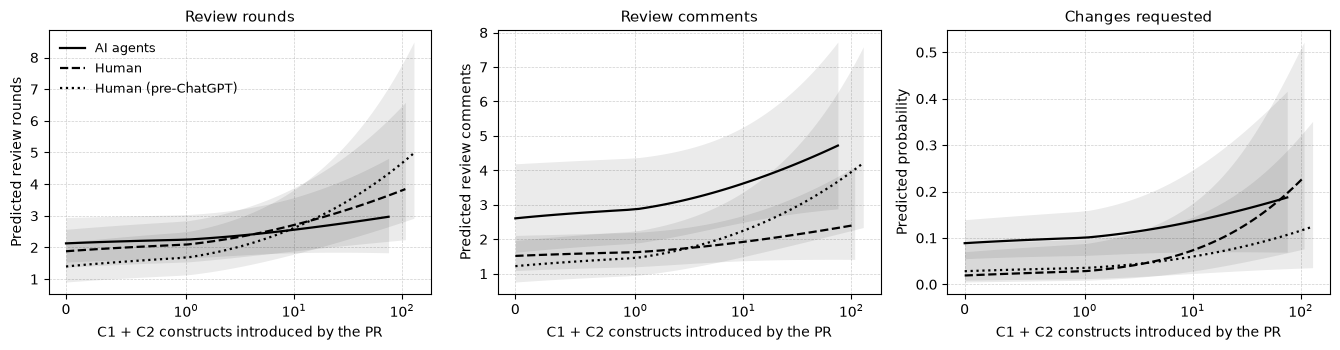

In [16]:
def design_info(res):
    """The fitted model's patsy design, named `model_spec` from statsmodels 0.15 on."""
    data = res.model.data
    for attr in ('model_spec', 'design_info'):
        if hasattr(data, attr):
            return getattr(data, attr)
    return data.orig_exog.design_info


def curve(res, d, outcome, iv, n=60):
    """Predicted outcome across the range of `iv`, other covariates at the group median."""
    lo, hi = d[iv].quantile([0.02, 0.98])
    grid = pd.DataFrame({iv: np.linspace(lo, hi, n)})
    for c in ['log_add', 'log_del', 'log_files']:
        grid[c] = d[c].median()
    grid['n_reviews_bot'] = d['n_reviews_bot'].fillna(0).median()
    grid['task'] = pd.Categorical(['feat'] * n, categories=TASK_ORDER)

    X = dmatrix(design_info(res), grid, return_type='dataframe')
    beta = res.params[X.columns]
    V = res.cov_params().loc[X.columns, X.columns]
    xb = X.values @ beta.values
    se = np.sqrt(np.einsum('ij,jk,ik->i', X.values, V.values, X.values))
    link = (lambda v: 1 / (1 + np.exp(-v))) if outcome == 'changes' else np.exp
    return grid[iv].values, link(xb), link(xb - 1.96 * se), link(xb + 1.96 * se)


LS = ['-', '--', ':']
for outcome in OUTCOMES:
    fig, ax = plt.subplots(figsize=(4.6, 3.6))
    for i, g in enumerate(GROUPS):
        d = df[df.group == g]
        res = fits[(g, outcome, 'c1c2_z')]
        x, y, lo, hi = curve(res, d, outcome, 'c1c2_z')
        xr = x * SD['log_c1c2'] + df['log_c1c2'].mean()      # back to log(1 + C1+C2)
        xc = np.expm1(xr)                                     # back to the C1+C2 count
        ax.plot(xc, y, ls=LS[i], color='black', lw=1.6, label=g)
        ax.fill_between(xc, lo, hi, color='black', alpha=0.08, lw=0)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('C1 + C2 constructs introduced by the PR', fontsize=14)
    ax.set_ylabel(('Predicted probability' if outcome == 'changes'
                   else f'Predicted {OUTCOMES[outcome].lower()}'), fontsize=14)
    ax.grid(True, ls='--', lw=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=13)
    ax.legend(fontsize=13, frameon=False)  # each panel is a standalone subfigure
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(FIG_DIR, f'rq4_predicted_effort_{outcome}.{ext}'),
                    bbox_inches='tight', dpi=200 if ext == 'png' else None)
    plt.show()


## 8. LaTeX tables

In [17]:
def to_tex(frame, name, **kw):
    path = os.path.join(TAB_DIR, name + '.tex')
    frame.to_latex(path, **kw)
    print('wrote', os.path.relpath(path, ROOT))


to_tex(descriptives, 'review_effort_descriptives', float_format='%.1f')
to_tex(main_tab, 'main_models', escape=True)
to_tex(pool_tab, 'pooled_interaction', escape=True)
to_tex(rob_tab, 'robustness', escape=True, na_rep='--')
to_tex(zinb.set_index(['group', 'outcome']), 'zinb_comparison', float_format='%.2f')
to_tex(spear.pivot_table(index=['group', 'predictor'], columns='outcome',
                         values=['rho', 'p_holm']), 'raw_spearman', float_format='%.3f')

wrote analysis/rq4_tables/review_effort_descriptives.tex
wrote analysis/rq4_tables/main_models.tex
wrote analysis/rq4_tables/pooled_interaction.tex
wrote analysis/rq4_tables/robustness.tex
wrote analysis/rq4_tables/zinb_comparison.tex
wrote analysis/rq4_tables/raw_spearman.tex


## 9. The numbers that go into the paper

In [18]:
print('=' * 78)
print('RQ4 SUMMARY')
print('=' * 78)
print(f'Sample: {len(df)} PRs across {df.repo.nunique()} repositories '
      f'({", ".join(f"{g}: {n}" for g, n in df.groupby("group", observed=True).size().items())})')
print(f'Human-only comment counts: {HUMAN_COMMENTS}')
print()
print('-- review effort available to explain --')
for g, d in df.groupby('group', observed=True):
    print(f'  {g:22s} zero human reviews {100*(d.rounds==0).mean():5.1f}%   '
          f'zero human comments {100*(d.comments==0).mean():5.1f}%   '
          f'median comments {d.comments.median():.0f}   '
          f'changes requested {100*d.changes.mean():.1f}%')
print()
print('-- proficiency effect, size-controlled (1 SD, Holm-adjusted within group) --')
for _, r in models.sort_values(['iv', 'outcome', 'group']).iterrows():
    sig = 'SIGNIFICANT' if r.p_holm < 0.05 else 'n.s.'
    print(f'  {IVS[r.iv]:22s} {OUTCOMES[r.outcome]:18s} {r.group:22s} '
          f'{r.est:5.2f} [{r.lo:.2f}, {r.hi:.2f}]  p={r.p_holm:.4f}  {sig}')
print()
print('-- slope differences vs. AI agents --')
for _, r in pooled[pooled.term != 'AI agents (reference slope)'].iterrows():
    sig = 'SIGNIFICANT' if r.p_holm < 0.05 else 'n.s.'
    print(f'  {IVS[r.iv]:22s} {OUTCOMES[r.outcome]:18s} {r.term:34s} '
          f'{r.est:5.2f} [{r.lo:.2f}, {r.hi:.2f}]  p={r.p:.4f}  p_holm={r.p_holm:.4f}  {sig}')

RQ4 SUMMARY
Sample: 1466 PRs across 246 repositories (AI agents: 489, Human: 500, Human (pre-ChatGPT): 477)
Human-only comment counts: True

-- review effort available to explain --
  AI agents              zero human reviews  31.7%   zero human comments  39.9%   median comments 1   changes requested 10.4%
  Human                  zero human reviews  33.4%   zero human comments  57.6%   median comments 0   changes requested 4.0%
  Human (pre-ChatGPT)    zero human reviews  36.9%   zero human comments  56.8%   median comments 0   changes requested 5.0%

-- proficiency effect, size-controlled (1 SD, Holm-adjusted within group) --
  C1+C2 constructs       Changes requested  AI agents               1.30 [0.94, 1.78]  p=0.5663  n.s.
  C1+C2 constructs       Changes requested  Human                   2.14 [1.31, 3.49]  p=0.0145  SIGNIFICANT
  C1+C2 constructs       Changes requested  Human (pre-ChatGPT)     1.53 [1.00, 2.34]  p=0.2100  n.s.
  C1+C2 constructs       Review comments    AI agen